In [1]:
import pandas as pd
import numpy as np

In [ ]:
dm=pd.read_excel(r"C:\Users\anadi\Desktop\Direct Marketing.xlsx")

In [ ]:
dm.shape

In [ ]:
dm.head()

In [ ]:
dm.info()

In [5]:
dm_cat=dm.select_dtypes(object)

In [7]:
dm_num=dm.select_dtypes(int)

In [9]:
dummies = pd.get_dummies(dm_cat)

In [11]:
dm1=pd.concat([dummies,dm_num],axis="columns")

In [13]:
dm1.head()

,Age_Middle,Age_Old,Age_Young,Gender_Female,Gender_Male,OwnHome_Own,OwnHome_Rent,Married_Married,Married_Single,Location_Close,Location_Far,History_First time,History_High,History_Low,History_Medium,Salary,Children,Catalogs,AmountSpent
0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,47500,0,6,755
1,True,False,False,False,True,False,True,False,True,True,False,False,True,False,False,63600,0,6,1318
2,False,False,True,True,False,False,True,False,True,True,False,False,False,True,False,13500,0,18,296
3,True,False,False,False,True,True,False,True,False,True,False,False,True,False,False,85600,1,18,2436
4,True,False,False,True,False,True,False,False,True,True,False,False,True,False,False,68400,0,12,1304


In [33]:
x=dm1.iloc[:,0:18]

In [35]:
x

,Age_Middle,Age_Old,Age_Young,Gender_Female,Gender_Male,OwnHome_Own,OwnHome_Rent,Married_Married,Married_Single,Location_Close,Location_Far,History_First time,History_High,History_Low,History_Medium,Salary,Children,Catalogs
0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,47500,0,6
1,True,False,False,False,True,False,True,False,True,True,False,False,True,False,False,63600,0,6
2,False,False,True,True,False,False,True,False,True,True,False,False,False,True,False,13500,0,18
3,True,False,False,False,True,True,False,True,False,True,False,False,True,False,False,85600,1,18
4,True,False,False,True,False,True,False,False,True,True,False,False,True,False,False,68400,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,True,True,False,False,True,False,True,True,False,True,False,False,False,19400,1,18
996,True,False,False,False,True,False,True,False,True,False,True,True,False,False,False,40500,1,18
997,False,True,False,False,True,True,False,False,True,True,False,False,False,False,True,44800,0,24
998,True,False,False,False,True,True,False,True,False,True,False,False,False,False,True,79000,2,18


In [43]:
y=dm1.iloc[:,18:19]

In [45]:
y

,AmountSpent
0,755
1,1318
2,296
3,2436
4,1304
...,...
995,384
996,1073
997,1417
998,671


In [47]:
import sklearn 

In [49]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=24)

In [51]:
xtrain.shape

(700, 18)

In [53]:
ytrain.shape

(700, 1)

In [55]:
xtest.shape

(300, 18)

In [57]:
ytest.shape

(300, 1)

In [59]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
rf=RandomForestRegressor(n_estimators=120)

In [63]:
rf=rf.fit(xtrain,ytrain)

C:\Users\Bianka\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [65]:
y_pred=rf.predict(xtest)

In [67]:
import sklearn.metrics as metrics 

In [69]:
mae = metrics.mean_absolute_error(ytest, y_pred)
mse = metrics.mean_squared_error(ytest, y_pred)

In [71]:
mae

285.925225925926

In [ ]:
mse

In [73]:
m = np.mean(ytest)

In [75]:
d = ytest-m

In [77]:
mae_base = np.mean(abs(d))
mse_base = np.mean(d**2)

In [79]:
mae_base

766.6349333333333

In [ ]:
mse_base

In [81]:
x.columns

Index(['Age_Middle', 'Age_Old', 'Age_Young', 'Gender_Female', 'Gender_Male',
       'OwnHome_Own', 'OwnHome_Rent', 'Married_Married', 'Married_Single',
       'Location_Close', 'Location_Far', 'History_First time', 'History_High',
       'History_Low', 'History_Medium', 'Salary', 'Children', 'Catalogs'],
      dtype='object')

In [83]:
features=pd.DataFrame(rf.feature_importances_,index=x.columns)

In [85]:
features

,0
Age_Middle,0.006085
Age_Old,0.006649
Age_Young,0.001854
Gender_Female,0.005089
Gender_Male,0.005848
OwnHome_Own,0.003277
OwnHome_Rent,0.003784
Married_Married,0.002800
Married_Single,0.002384
Location_Close,0.029989


<BarContainer object of 18 artists>

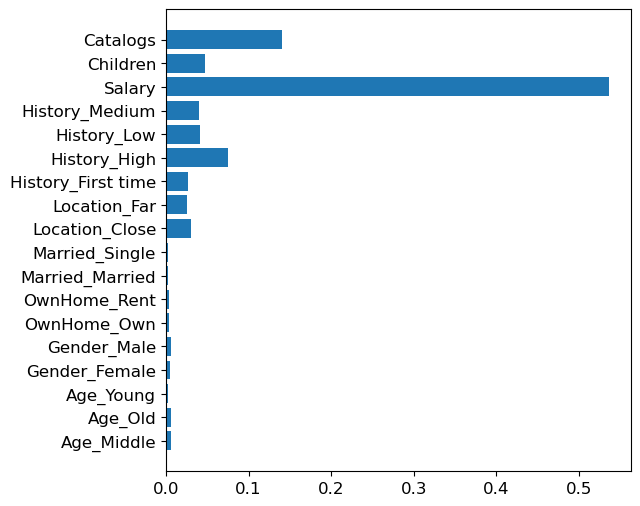

In [89]:
from matplotlib import pyplot as plt
plt.rcParams.update({"figure.figsize":(6,6)})
plt.rcParams.update({"font.size":12})
feature_names=x.columns # lists out the column names for the x #
plt.barh(feature_names, rf.feature_importances_)